In [40]:
import numpy as np
import random
import argparse
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [41]:
def get_dataset_name(dataset_id, nnunet_raw):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [
        d for d in os.listdir(nnunet_raw)
        if d.startswith(f"Dataset{dataset_id}") and os.path.isdir(os.path.join(nnunet_raw, d))
    ]
    if len(dataset_name) != 1:
        raise RuntimeError(f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1")
    return dataset_name[0]

def extract_params(model_dir):
    metrics_file = f"{model_dir}/model_analysis.json"
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['parameters']['total']

def get_dice(results_dir, dataset_name, trainer, plans, cfg, fold=0, split="val"):
    model_dir = f"{results_dir}/{dataset_name}/{trainer}__{plans}__{cfg}"
    params = extract_params(model_dir)
    if split != "val":
        raise ValueError("Only split=val supported")
    metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
    with open(metrics_file, "r") as f:
        metrics = json.load(f)
    return {
        "dice": metrics["foreground_mean"]["Dice"] * 100,
        "params": params,
    }

In [44]:
from types import SimpleNamespace

def get_args(train_dataset_id, batch_size, trainer):
    args = dict(
        train_dataset_id=train_dataset_id,
        results_dir="data/nnUNet_results/nnunet",
        nas_dir="results/nas_metrics",
        trainer=trainer,
        plans="nnUNetPlans",
        fold=0,
        batches=batch_size,
        cfgs=[
            "2d_tiny1", "2d_tiny2", "2d_tiny4", 
            "2d_tiny8", "2d_tiny16",
            "2d_tiny32", "2d_tiny64",
             "2d_tiny128", "2d_tiny256", 
            "2d",
        ]
    )
    return SimpleNamespace(**args)


def select_precollapse_config_from_jacobian(params_list, jacobian_list, pre_collapse_rank=1, min_seg=2, method="two_line", combined_distance_weight=1.0):
    x = np.asarray(params_list, dtype=float)
    y = np.asarray([np.nan if pd.isna(v) else float(v) for v in jacobian_list], dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if valid.sum() < (2 * min_seg + 1):
        return None, None, None

    valid_idx = np.flatnonzero(valid)
    xv = np.log10(x[valid])
    yv = np.asarray(y[valid], dtype=float)

    n = len(xv)
    best = None
    best_obj = np.inf

    for b in range(min_seg - 1, n - min_seg):
        x1, y1 = xv[: b + 1], yv[: b + 1]
        x2, y2 = xv[b + 1 :], yv[b + 1 :]

        if method == "two_line":
            p1 = np.polyfit(x1, y1, 1)
            p2 = np.polyfit(x2, y2, 1)

            y1_hat = p1[0] * x1 + p1[1]
            y2_hat = p2[0] * x2 + p2[1]
            obj = np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2)

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "p1": p1,
                "p2": p2,
                "y1_hat": y1_hat,
                "y2_hat": y2_hat,
                "left_idx": valid_idx[: b + 1].copy(),
                "right_idx": valid_idx[b + 1 :].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        elif method == "avg_distance":
            d1 = np.abs(np.diff(y1))
            d2 = np.abs(np.diff(y2))
            total1 = float(np.sum(d1)) if len(d1) > 0 else np.inf
            total2 = float(np.sum(d2)) if len(d2) > 0 else np.inf
            obj = total1 + total2

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "total_left": total1,
                "total_right": total2,
                "left_idx": valid_idx[: b + 1].copy(),
                "right_idx": valid_idx[b + 1 :].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        elif method == "combined":
            p1 = np.polyfit(x1, y1, 1)
            p2 = np.polyfit(x2, y2, 1)
            y1_hat = p1[0] * x1 + p1[1]
            y2_hat = p2[0] * x2 + p2[1]
            sse = float(np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2))

            d1 = np.abs(np.diff(y1))
            d2 = np.abs(np.diff(y2))
            total_dist = float(np.sum(d1) + np.sum(d2))

            obj = sse + float(combined_distance_weight) * total_dist

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "sse": sse,
                "total_dist": total_dist,
                "combined_distance_weight": float(combined_distance_weight),
                "p1": p1,
                "p2": p2,
                "y1_hat": y1_hat,
                "y2_hat": y2_hat,
                "left_idx": valid_idx[: b + 1].copy(),
                "right_idx": valid_idx[b + 1 :].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        else:
            raise ValueError(f"Unknown split method: {method}")

        if obj < best_obj:
            best_obj = obj
            best = info

    best_b = int(best["b"])
    pick_valid_pos = best_b + int(pre_collapse_rank)
    if pick_valid_pos >= len(valid_idx):
        pick_valid_pos = len(valid_idx) - 1

    pick_idx = int(valid_idx[pick_valid_pos])
    boundary_idx = int(valid_idx[best_b + 1])
    return pick_idx, boundary_idx, best


def batch_equivalent_l2(scores):
    scores = np.asarray(scores, dtype=np.float64)
    return float(np.sqrt(np.sum(scores * scores, dtype=np.float64)))

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs1_l2agg_minmax_across_cfgs_two_line_change_norm.png


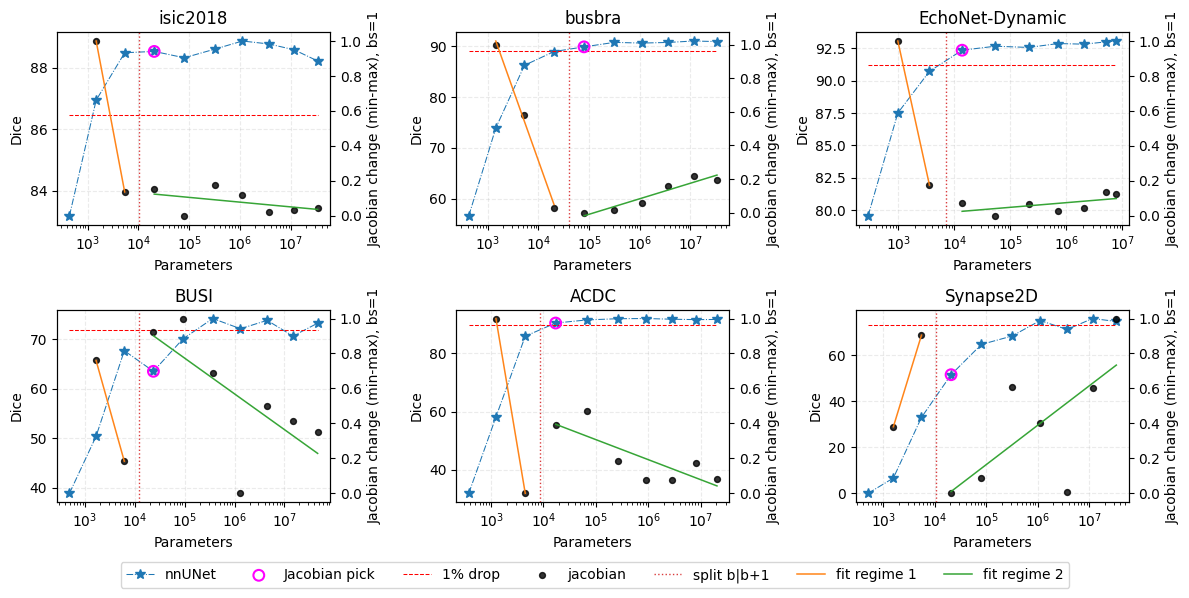

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs2_l2agg_minmax_across_cfgs_two_line_change_norm.png


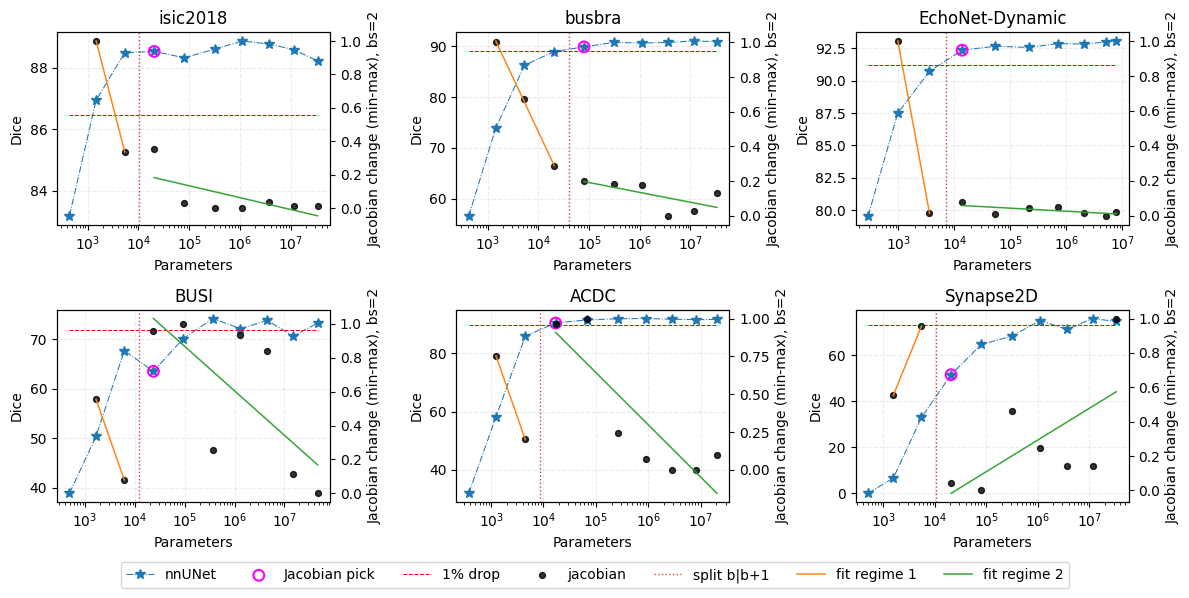

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs4_l2agg_minmax_across_cfgs_two_line_change_norm.png


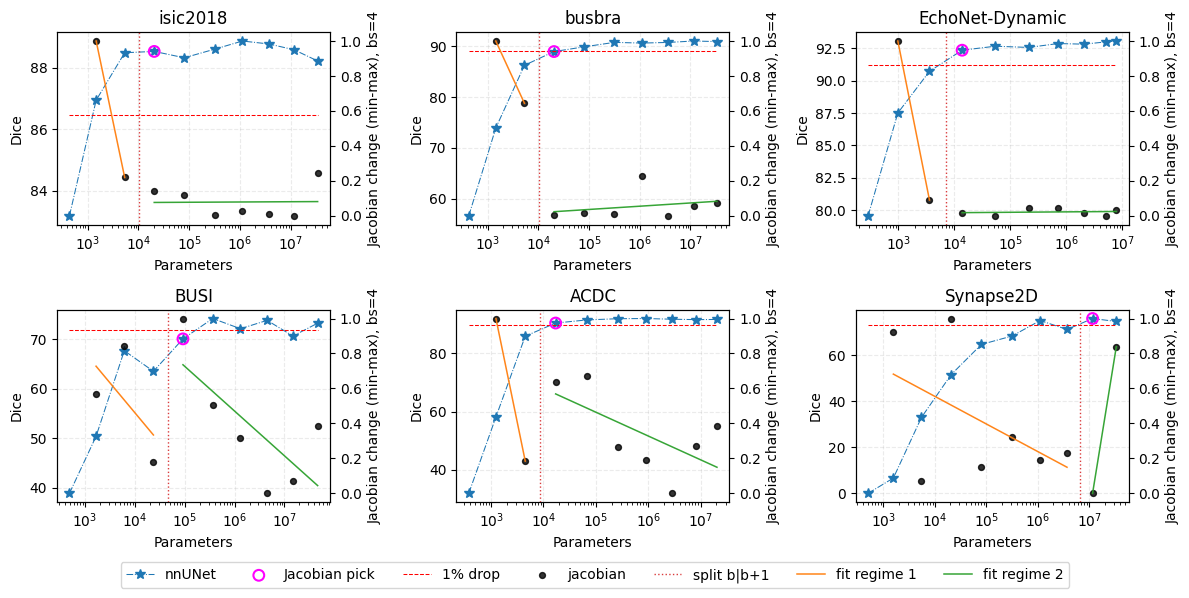

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs8_l2agg_minmax_across_cfgs_two_line_change_norm.png


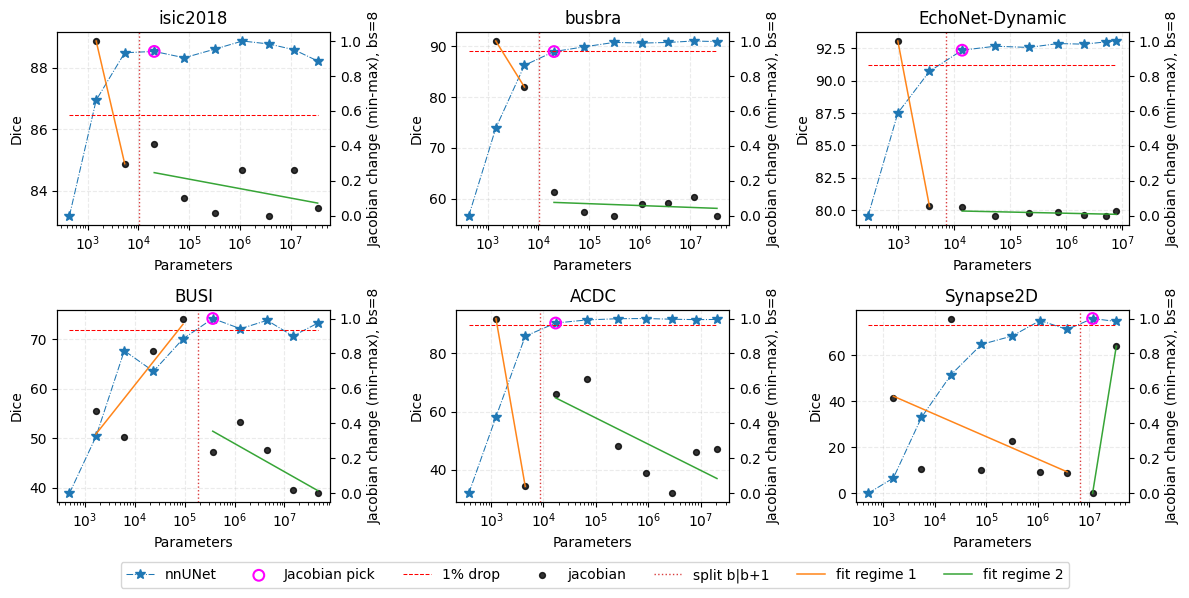

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs16_l2agg_minmax_across_cfgs_two_line_change_norm.png


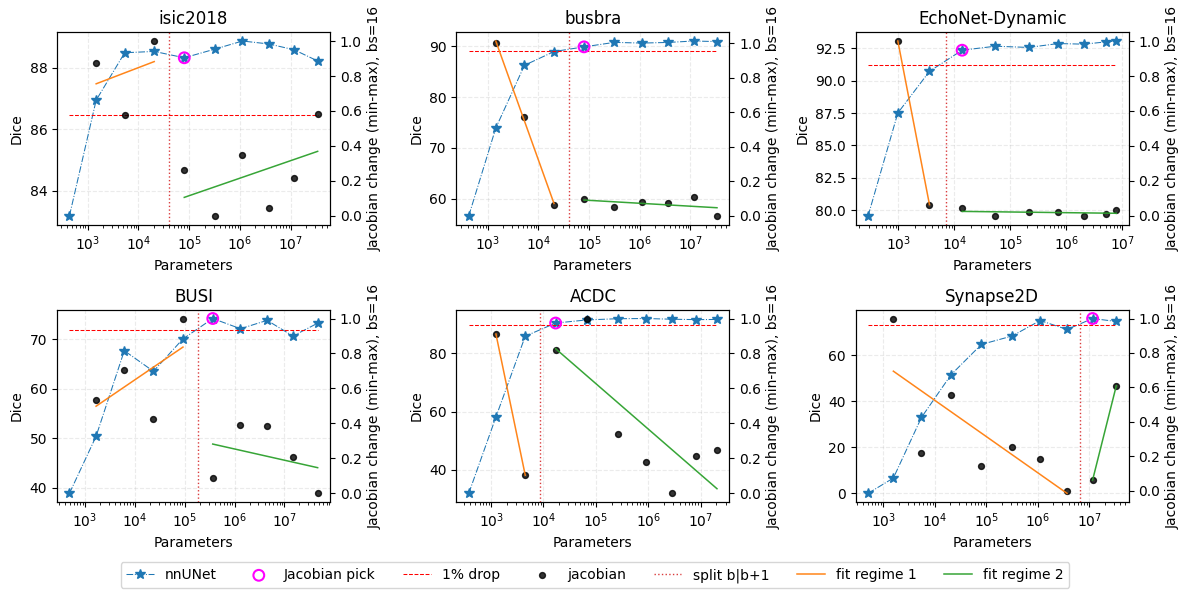

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs32_l2agg_minmax_across_cfgs_two_line_change_norm.png


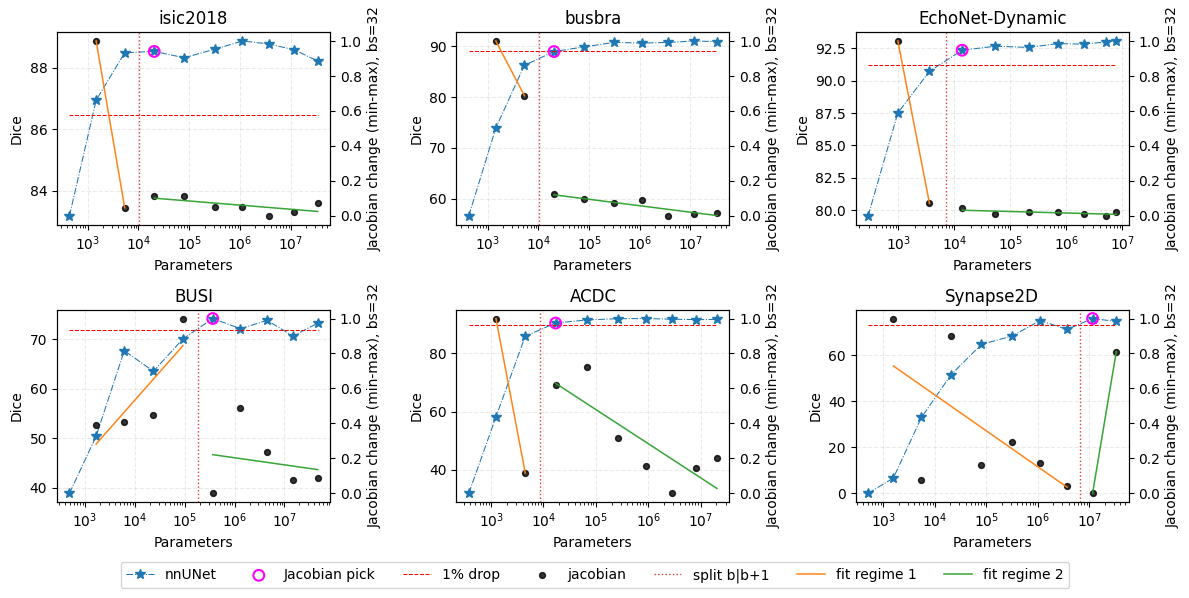

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs64_l2agg_minmax_across_cfgs_two_line_change_norm.png


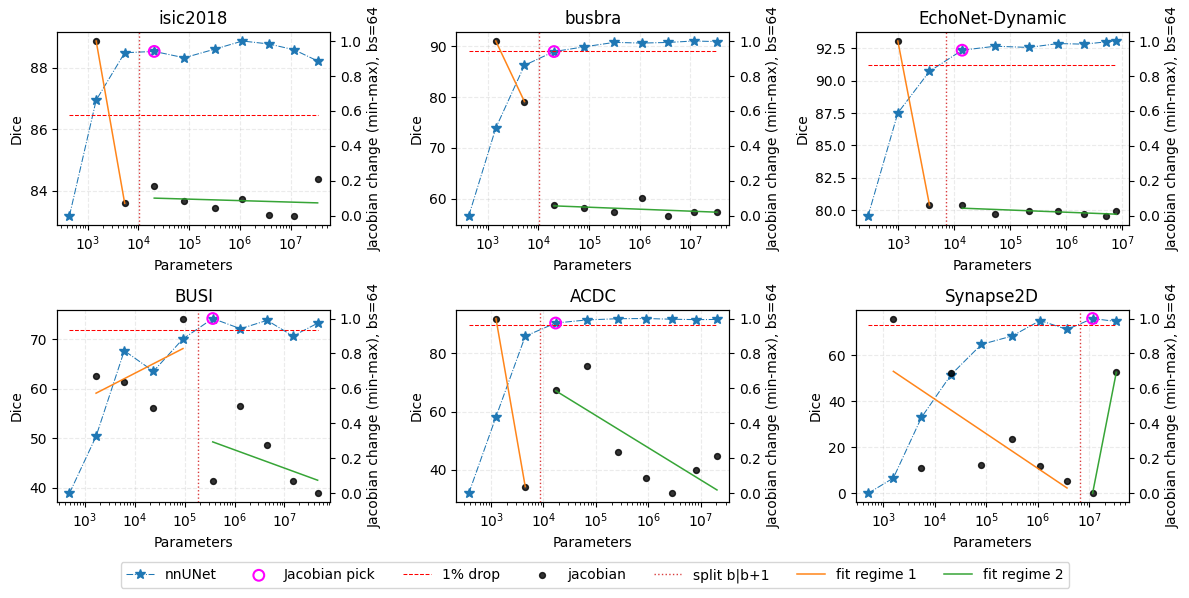

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bs128_l2agg_minmax_across_cfgs_two_line_change_norm.png


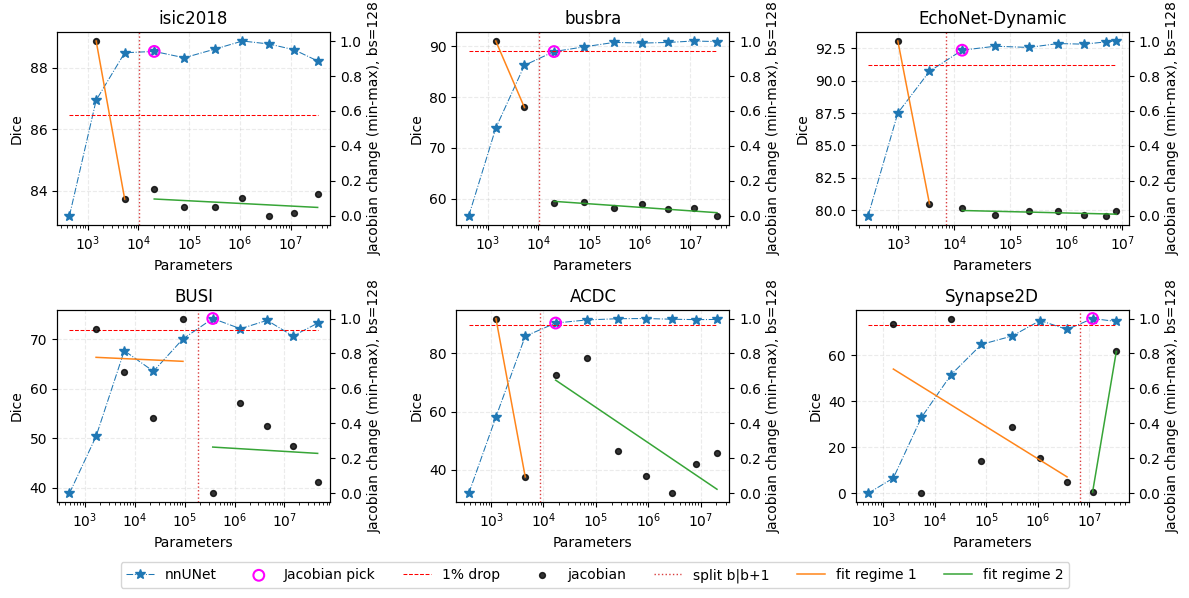

saved to results/analysis/jacobian_batches/two_line/jacobian_sim_bsall_l2agg_minmax_across_cfgs_two_line_change_norm.png


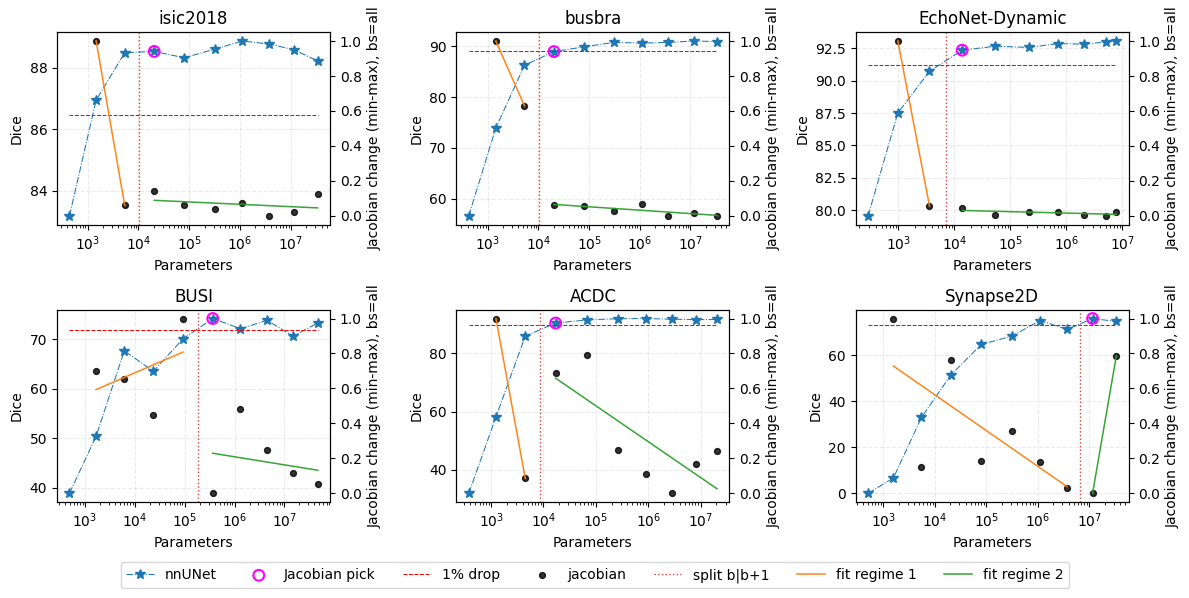

saved to results/analysis/jacobian_batches/jacobian_picks_l2agg_minmax_across_cfgs_two_line_change_norm.csv


,sim_batch_size,used_batch_size,dataset,split_method,combined_distance_weight,picked_cfg,picked_idx,boundary_idx,split_left_idx,split_right_idx
0,1,1,Dataset300_isic2018,two_line,0,2d_tiny8,3,3,2,3
1,1,1,Dataset301_busbra,two_line,0,2d_tiny16,4,4,3,4
2,1,1,Dataset302_EchoNet-Dynamic,two_line,0,2d_tiny8,3,3,2,3
3,1,1,Dataset304_BUSI,two_line,0,2d_tiny8,3,3,2,3
4,1,1,Dataset306_ACDC,two_line,0,2d_tiny8,3,3,2,3
5,1,1,Dataset305_Synapse2D,two_line,0,2d_tiny8,3,3,2,3
6,2,2,Dataset300_isic2018,two_line,0,2d_tiny8,3,3,2,3
7,2,2,Dataset301_busbra,two_line,0,2d_tiny16,4,4,3,4
8,2,2,Dataset302_EchoNet-Dynamic,two_line,0,2d_tiny8,3,3,2,3
9,2,2,Dataset304_BUSI,two_line,0,2d_tiny8,3,3,2,3


In [47]:
# Settings
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

dataset_ids = [300, 301, 302, 304, 306, 305]

results_dir = "data/nnUNet_results/nnunet"
nnunet_raw = "data/nnUNet_raw"
nas_dir = "results/nas_metrics"
trainer = "nnUNetTrainer_100epochs"
plans = "nnUNetPlans"
fold = 0
source_batches = "all"  # read ..._batch_jacobian_b{source_batches}.csv

sim_batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, "all"]
use_relative_change = True
normalize_metric = True
jacobian_precollapse_rank = 1  # 1=last before collapse, 2=second-last
min_seg = 2
random_seed = 42
split_method = "two_line"  # "two_line", "avg_distance", or "combined"
combined_distance_weight = 0#.25
plot_fit_lines = True

save_dir = "results/analysis/jacobian_batches"
os.makedirs(save_dir, exist_ok=True)

pick_rows = []

for sim_bs in sim_batch_sizes:
    fig = plt.figure(figsize=(12, 6))

    for i, dataset_id in enumerate(dataset_ids):
        dataset_name = get_dataset_name(dataset_id, nnunet_raw)

        params_map = {}
        dice_map = {}
        for cfg in cfgs:
            m = get_dice(results_dir, dataset_name, trainer, plans, cfg, fold)
            params_map[cfg] = m["params"]
            dice_map[cfg] = m["dice"]
        
        batch_path = Path(nas_dir) / f"{dataset_name}_batch_jacobian_b{source_batches}.csv"
        df = pd.read_csv(batch_path)
        df = df[df["cfg"].isin(cfgs)]

        vals_per_cfg = {}
        for cfg in cfgs:
            vals = df.loc[df["cfg"] == cfg, "jacobian"].astype(float).to_numpy()
            vals_per_cfg[cfg] = vals

        if sim_bs == "all":
            use_bs = "all"
        else:
            use_bs = int(sim_bs)

        jac_curve_raw = []
        for cfg in cfgs:
            vals = vals_per_cfg[cfg]
            # random.seed(random_seed)
            random.shuffle(vals)
            if use_bs != "all":
                if len(vals) < use_bs:
                    raise ValueError(f"{dataset_name} {cfg}: need at least {use_bs} per-image rows, found {len(vals)}")
                vals = vals[:use_bs]
            jac_curve_raw.append(batch_equivalent_l2(vals))

        jac_curve_raw = np.asarray(jac_curve_raw, dtype=float)
        jmin = np.min(jac_curve_raw)
        jmax = np.max(jac_curve_raw)
        if jmax > jmin:
            jac_curve = ((jac_curve_raw - jmin) / (jmax - jmin)).tolist()
        else:
            jac_curve = np.zeros_like(jac_curve_raw).tolist()

        jac_plot_curve = jac_curve
        if use_relative_change:
            jac_plot_curve = [np.nan] + [abs(jac_curve[j] - jac_curve[j - 1]) for j in range(1, len(jac_curve))]

        if normalize_metric:
            valid = [x for x in jac_plot_curve if not np.isnan(x)]
            if len(valid) > 0 and (max(valid) - min(valid)) > 0:
                jac_plot_curve = [np.nan if np.isnan(x) else (x - min(valid)) / (max(valid) - min(valid)) for x in jac_plot_curve]

        params_list = [params_map[cfg] for cfg in cfgs]
        dice_list = [dice_map[cfg] for cfg in cfgs]

        pick_input_curve = jac_plot_curve if use_relative_change else jac_curve
        pick_idx, boundary_idx, fit_info = select_precollapse_config_from_jacobian(
            params_list,
            pick_input_curve,
            pre_collapse_rank=jacobian_precollapse_rank,
            min_seg=min_seg,
            method=split_method,
            combined_distance_weight=combined_distance_weight,
        )

        pick_rows.append(
            {
                "sim_batch_size": sim_bs,
                "used_batch_size": use_bs,
                "dataset": dataset_name,
                "split_method": split_method,
                "combined_distance_weight": combined_distance_weight,
                "picked_cfg": cfgs[pick_idx] if pick_idx is not None else None,
                "picked_idx": pick_idx,
                "boundary_idx": boundary_idx,
                "split_left_idx": fit_info["boundary_left_idx"] if fit_info is not None else None,
                "split_right_idx": fit_info["boundary_right_idx"] if fit_info is not None else None,
            }
        )

        plt.subplot(2, len(dataset_ids) // 2, i + 1)
        ax = plt.gca()

        label = "nnUNet" if i == 0 else "_nolegend_"
        ax.plot(params_list, dice_list, marker="*", linestyle="dashdot", linewidth=0.75, markersize=7, color="C0", label=label)

        ax2 = ax.twinx()
        jlabel = "jacobian" if i == 0 else "_nolegend_"
        ax2.scatter(params_list, jac_plot_curve, s=18, color="black", alpha=0.8, label=jlabel)

        if fit_info is not None:
            bl = fit_info["boundary_left_idx"]
            br = fit_info["boundary_right_idx"]
            split_x = np.sqrt(params_list[bl] * params_list[br])
            split_label = "split b|b+1" if i == 0 else "_nolegend_"
            ax2.axvline(split_x, color="tab:red", linestyle=":", linewidth=1.0, alpha=0.9, label=split_label)

        if fit_info is not None and split_method in ("two_line", "combined") and plot_fit_lines:
            left_idx = fit_info["left_idx"]
            right_idx = fit_info["right_idx"]
            y1_hat = fit_info["y1_hat"]
            y2_hat = fit_info["y2_hat"]

            x_left = [params_list[k] for k in left_idx]
            x_right = [params_list[k] for k in right_idx]

            fit1_label = "fit regime 1" if i == 0 else "_nolegend_"
            fit2_label = "fit regime 2" if i == 0 else "_nolegend_"
            ax2.plot(x_left, y1_hat, linestyle="-", linewidth=1.1, color="tab:orange", alpha=0.95, label=fit1_label)
            ax2.plot(x_right, y2_hat, linestyle="-", linewidth=1.1, color="tab:green", alpha=0.95, label=fit2_label)

        if pick_idx is not None:
            pick_label = "Jacobian pick" if i == 0 else "_nolegend_"
            ax.scatter(
                params_list[pick_idx],
                dice_list[pick_idx],
                marker="o",
                s=60,
                facecolors="none",
                edgecolors="magenta",
                linewidths=1.5,
                zorder=7,
                label=pick_label,
            )

        drop_label = "1% drop" if i == 0 else "_nolegend_"
        # dice_range = max(dice_list) - min(dice_list)
        # drop_y = dice_list[-1] - 0. * dice_range
        drop_y = dice_list[-1] * (1 - 0.02)
        ax.hlines(drop_y, params_list[0], params_list[-1], colors="red", linestyles="dashed", linewidth=0.75, label=drop_label)

        ax.set_xlabel("Parameters")
        ax.set_ylabel("Dice")
        y_base = "Jacobian change" if use_relative_change else "Jacobian"
        y_norm = " (min-max)" if normalize_metric else ""
        ax2.set_ylabel(f"{y_base}{y_norm}, bs={use_bs}")
        ax.set_title(f"{dataset_name.split('_')[1]}")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.25, linestyle="--")

    fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=8)
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    suffix = "_change" if use_relative_change else ""
    if normalize_metric:
        suffix += "_norm"
    os.makedirs(f"{save_dir}/{split_method}", exist_ok=True)
    out_path = f"{save_dir}/{split_method}/jacobian_sim_bs{use_bs}_l2agg_minmax_across_cfgs_{split_method}{suffix}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"saved to {out_path}")
    plt.show()

pick_df = pd.DataFrame(pick_rows)
suffix = "_change" if use_relative_change else ""
if normalize_metric:
    suffix += "_norm"
pick_csv = f"{save_dir}/jacobian_picks_l2agg_minmax_across_cfgs_{split_method}{suffix}.csv"
pick_df.to_csv(pick_csv, index=False)
print(f"saved to {pick_csv}")
pick_df